1: Data set


In [1]:
import numpy as np
import pandas as pd

# Set seed for reproducibility
np.random.seed(42)

def generate_dataset(num_samples=1000):
    num_subjects = np.random.randint(1, 7, num_samples)          # 1–6 subjects
    days_until_exam = np.random.randint(1, 31, num_samples)      # 1–30 days
    difficulty = np.random.randint(1, 11, num_samples)           # 1–10 difficulty
    available_hours = np.random.randint(1, 13, num_samples)      # 1–12 hrs/day

    # Output: recommended study hours per subject per day
    recommended_hours = (difficulty * 0.5 + (1 / days_until_exam) * 10 + available_hours * 0.3) / num_subjects
    recommended_hours = np.clip(recommended_hours, 0.5, 12)  # keep it realistic

    df = pd.DataFrame({
        'num_subjects': num_subjects,
        'days_until_exam': days_until_exam,
        'difficulty': difficulty,
        'available_hours': available_hours,
        'recommended_hours': recommended_hours
    })
    return df

df = generate_dataset(1000)
print(df.head())
print(df.describe())

   num_subjects  days_until_exam  difficulty  available_hours  \
0             4               22           2                8   
1             5               21           2                9   
2             3                6           4                4   
3             5                6           3                6   
4             5               23           4                9   

   recommended_hours  
0           0.963636  
1           0.835238  
2           1.622222  
3           0.993333  
4           1.026957  
       num_subjects  days_until_exam   difficulty  available_hours  \
count   1000.000000      1000.000000  1000.000000      1000.000000   
mean       3.457000        15.403000     5.412000         6.477000   
std        1.714377         8.814663     2.842593         3.488788   
min        1.000000         1.000000     1.000000         1.000000   
25%        2.000000         8.000000     3.000000         3.000000   
50%        4.000000        15.000000     5.000000  

2. Preprocess Data

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df[['num_subjects', 'days_until_exam', 'difficulty', 'available_hours']].values
y = df['recommended_hours'].values

# Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 800
Testing samples: 200


3: MLP Model

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def build_model():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(4,)),  # Input layer → Hidden layer 1
        Dense(32, activation='relu'),                     # Hidden layer 2
        Dense(1)                                          # Output layer (regression)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model = build_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

 Non-trainable params: 0 (0.00 B)

4. Trainin Data

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.3177 - mae: 2.0111 - val_loss: 8.3571 - val_mae: 1.9025
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.2611 - mae: 1.3891 - val_loss: 5.1682 - val_mae: 1.4795
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.2046 - mae: 1.1098 - val_loss: 3.0115 - val_mae: 1.1092
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.8507 - mae: 0.8595 - val_loss: 1.8749 - val_mae: 0.8781
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2992 - mae: 0.7961 - val_loss: 1.3563 - val_mae: 0.8176
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.9555 - mae: 0.6933 - val_loss: 1.1333 - val_mae: 0.7235
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7963 - mae: 0.6303 - val_loss: 0.9688 - val_mae: 0.6735
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6998 - mae: 0.5863 - val_loss: 0.8890 - val_mae: 0.6326
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.63

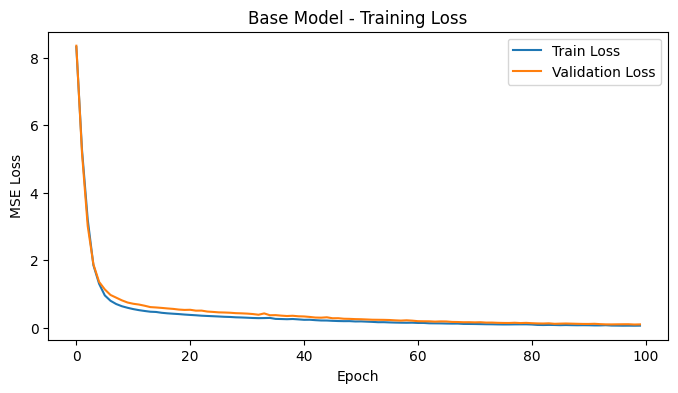

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0442 - mae: 0.1313  
Test MSE: 0.0442 | Test MAE: 0.1313


In [4]:
import matplotlib.pyplot as plt

# Train the base model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Base Model - Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

# Evaluate on test set
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f"Test MSE: {test_loss:.4f} | Test MAE: {test_mae:.4f}")

5. 3 experiments

In [5]:
# ── Experiment 1: Vary number of epochs ──────────────────────────────
results_epochs = {}
for epochs in [50, 100, 200]:
    m = build_model()
    h = m.fit(X_train, y_train, epochs=epochs, batch_size=32,
              validation_split=0.2, verbose=0)
    loss, mae = m.evaluate(X_test, y_test, verbose=0)
    results_epochs[epochs] = {'mse': loss, 'mae': mae}
    print(f"Epochs={epochs} → Test MSE: {loss:.4f}, MAE: {mae:.4f}")

# ── Experiment 2: Vary neuron sizes ──────────────────────────────────
architectures = [(32, 16), (64, 32), (128, 64)]
results_arch = {}
for (n1, n2) in architectures:
    m = Sequential([
        Dense(n1, activation='relu', input_shape=(4,)),
        Dense(n2, activation='relu'),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    m.fit(X_train, y_train, epochs=100, batch_size=32,
          validation_split=0.2, verbose=0)
    loss, mae = m.evaluate(X_test, y_test, verbose=0)
    results_arch[f"{n1}/{n2}"] = {'mse': loss, 'mae': mae}
    print(f"Architecture={n1}/{n2} → Test MSE: {loss:.4f}, MAE: {mae:.4f}")

# ── Experiment 3: Vary dataset size ──────────────────────────────────
results_size = {}
for size in [500, 1000, 2000]:
    df_temp = generate_dataset(size)
    X_temp = df_temp[['num_subjects', 'days_until_exam', 'difficulty', 'available_hours']].values
    y_temp = df_temp['recommended_hours'].values
    X_tr, X_te, y_tr, y_te = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)
    sc = StandardScaler()
    X_tr = sc.fit_transform(X_tr)
    X_te = sc.transform(X_te)
    m = build_model()
    m.fit(X_tr, y_tr, epochs=100, batch_size=32, validation_split=0.2, verbose=0)
    loss, mae = m.evaluate(X_te, y_te, verbose=0)
    results_size[size] = {'mse': loss, 'mae': mae}
    print(f"Dataset size={size} → Test MSE: {loss:.4f}, MAE: {mae:.4f}")

Epochs=50 → Test MSE: 0.1080, MAE: 0.2271
Epochs=100 → Test MSE: 0.0646, MAE: 0.1463
Epochs=200 → Test MSE: 0.0188, MAE: 0.0853
Architecture=32/16 → Test MSE: 0.1112, MAE: 0.2498
Architecture=64/32 → Test MSE: 0.0479, MAE: 0.1400
Architecture=128/64 → Test MSE: 0.0163, MAE: 0.0778


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Dataset size=500 → Test MSE: 0.1568, MAE: 0.2599


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Dataset size=1000 → Test MSE: 0.0794, MAE: 0.1562


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Dataset size=2000 → Test MSE: 0.0273, MAE: 0.0823


Plotting resulsts

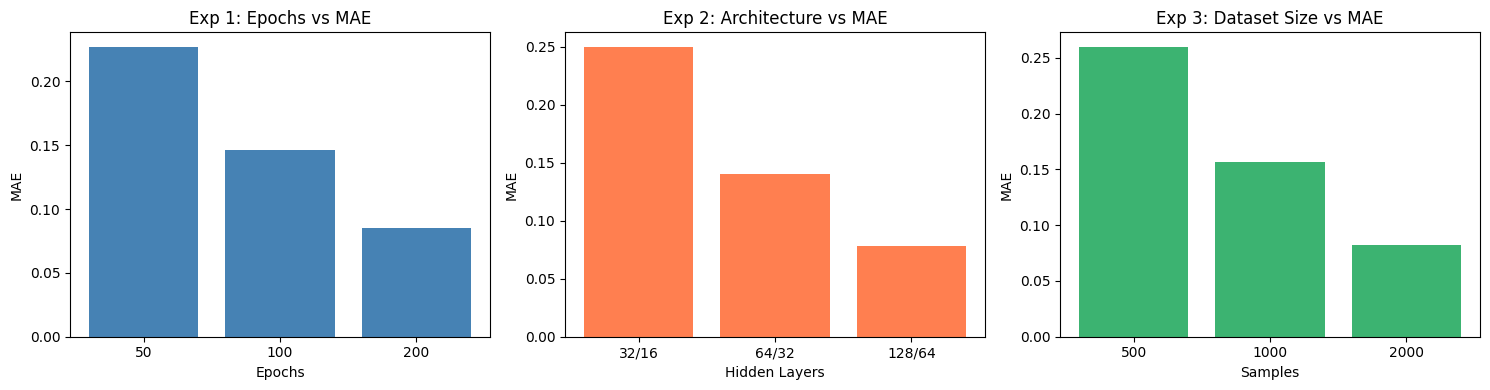

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Experiment 1 - Epochs
axes[0].bar([str(k) for k in results_epochs.keys()],
            [v['mae'] for v in results_epochs.values()], color='steelblue')
axes[0].set_title('Exp 1: Epochs vs MAE')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('MAE')

# Experiment 2 - Architecture
axes[1].bar(list(results_arch.keys()),
            [v['mae'] for v in results_arch.values()], color='coral')
axes[1].set_title('Exp 2: Architecture vs MAE')
axes[1].set_xlabel('Hidden Layers')
axes[1].set_ylabel('MAE')

# Experiment 3 - Dataset size
axes[2].bar([str(k) for k in results_size.keys()],
            [v['mae'] for v in results_size.values()], color='mediumseagreen')
axes[2].set_title('Exp 3: Dataset Size vs MAE')
axes[2].set_xlabel('Samples')
axes[2].set_ylabel('MAE')

plt.tight_layout()
plt.show()